# Dengue Modeling Exploration — Singapore

This notebook performs the first modeling pass for the dengue outbreak prediction project.

## Goals
- Load the processed weekly dengue-weather dataset
- Define an outbreak label from the weekly dengue signal
- Create lag-based predictive features
- Train baseline models for multiple prediction horizons
- Compare dengue predictability against the flu baseline

## Modeling scope for this notebook
This is the first exploratory dengue notebook, so the focus is on:
- simple outbreak labeling
- lag-based features
- baseline Random Forest models
- time-aware train/test evaluation

## Planned horizons
We will predict whether an outbreak occurs at:

- 1 week ahead
- 2 weeks ahead
- 3 weeks ahead
- 4 weeks ahead

## Notes
- This notebook uses the processed output from `01_dengue_data_build.ipynb`
- Dengue has fewer years and fewer large outbreak cycles than flu, so lower and noisier performance is expected
- We focus on the horizon-performance pattern, not just absolute accuracy

In [54]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

sys.path.append(str(Path("..").resolve()))

from config import savefig, print_config_summary

print_config_summary()

===== CONFIG SUMMARY =====
Base Dir: /Users/suvo/Projects/disease-outbreak
Default Disease: flu
Default Region: illinois
Forecast Horizons: [1, 2, 3, 4]
Default Lags: [1, 2, 3, 4]
Default Outbreak Quantile: 0.85
Raw Data Dir: /Users/suvo/Projects/disease-outbreak/data/raw
Interim Data Dir: /Users/suvo/Projects/disease-outbreak/data/interim
Processed Data Dir: /Users/suvo/Projects/disease-outbreak/data/processed
Figures Dir: /Users/suvo/Projects/disease-outbreak/outputs/figures
Tables Dir: /Users/suvo/Projects/disease-outbreak/outputs/tables
Models Dir: /Users/suvo/Projects/disease-outbreak/outputs/models
Flu Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/fluview_il_201040_202652.json
Flu Weather Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/weather_openmeteo_springfield_il_2010-10-01_2026-04-10.json


In [55]:
df = pd.read_parquet("../data/processed/dengue/dengue_weekly_merged.parquet").copy()

print(df.shape)
display(df.head())

(261, 7)


,week_start,number,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum
0,2014-01-05,436,27.520000,24.120000,15.5,15.240000,14.884000
1,2014-01-12,479,27.871429,23.828571,40.8,13.442857,17.071429
2,2014-01-19,401,27.300000,23.885714,5.9,20.642857,17.952857
3,2014-01-26,336,27.142857,23.214286,1.5,19.128571,19.302857
4,2014-02-02,234,28.271429,22.828571,0.7,19.042857,22.348571


In [56]:
df["week_start"] = pd.to_datetime(df["week_start"])
df = df.sort_values("week_start").reset_index(drop=True)

print(df.dtypes)

week_start                 datetime64[us]
number                              int64
temperature_2m_max                float64
temperature_2m_min                float64
precipitation_sum                 float64
wind_speed_10m_max                float64
shortwave_radiation_sum           float64
dtype: object


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/dengue/dengue_cases_model_input.png


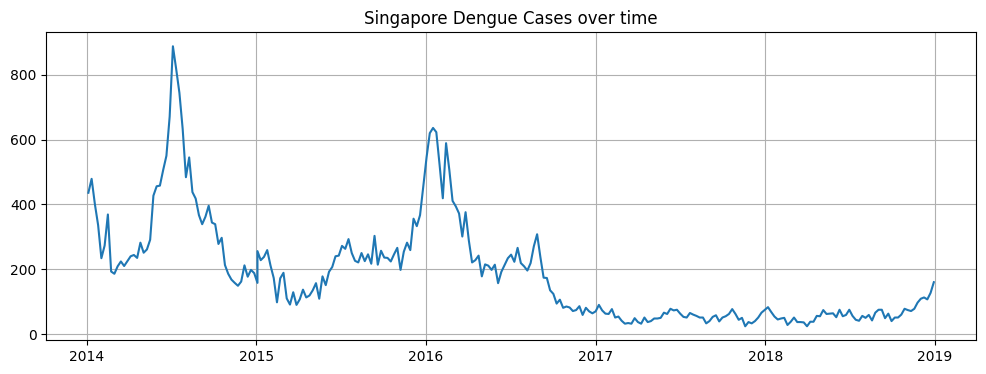

In [57]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["week_start"], df["number"])
ax.set_title("Singapore Dengue Cases over time")
ax.grid(True)

savefig(fig, "dengue_cases_model_input.png", subdir="dengue")
plt.show()

In [58]:
for q in [0.80, 0.85, 0.90]:
    print(f"Quantile {q:.2f}: {df['number'].quantile(q):.4f}")

Quantile 0.80: 272.0000
Quantile 0.85: 336.0000
Quantile 0.90: 401.0000


In [59]:
outbreak_quantile = 0.90
threshold = df["number"].quantile(outbreak_quantile)

df["outbreak"] = (df["number"] >= threshold).astype(int)

print("Threshold:", threshold)
print("Outbreak rate:", df["outbreak"].mean())

Threshold: 401.0
Outbreak rate: 0.10344827586206896


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/dengue/dengue_outbreak_labeling_85th_percentile.png


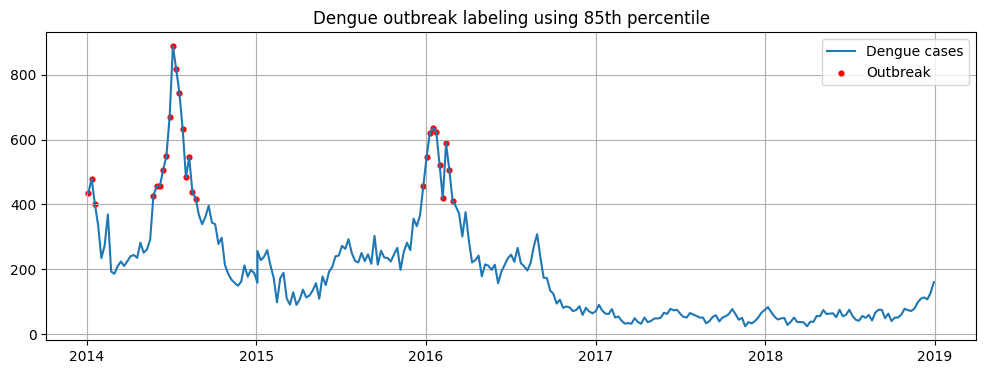

In [60]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["week_start"], df["number"], label="Dengue cases")

mask = df["outbreak"] == 1
ax.scatter(
    df.loc[mask, "week_start"],
    df.loc[mask, "number"],
    color="red",
    s=12,
    label="Outbreak"
)

ax.set_title("Dengue outbreak labeling using 85th percentile")
ax.legend()
ax.grid(True)

savefig(fig, "dengue_outbreak_labeling_85th_percentile.png", subdir="dengue")
plt.show()

In [61]:
for lag in [1, 2, 3]:
    df[f"cases_lag_{lag}"] = df["number"].shift(lag)

lag_cols = [f"cases_lag_{lag}" for lag in [1, 2, 3]]

df_lagged = df.dropna(subset=lag_cols).reset_index(drop=True)

print(df_lagged.shape)
display(df_lagged.head())

(258, 11)


,week_start,number,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,outbreak,cases_lag_1,cases_lag_2,cases_lag_3
0,2014-01-26,336,27.142857,23.214286,1.5,19.128571,19.302857,0,401.0,479.0,436.0
1,2014-02-02,234,28.271429,22.828571,0.7,19.042857,22.348571,0,336.0,401.0,479.0
2,2014-02-09,273,29.614286,23.414286,3.1,13.814286,21.327143,0,234.0,336.0,401.0
3,2014-02-16,369,29.914286,24.557143,8.3,15.828571,21.317143,0,273.0,234.0,336.0
4,2014-02-23,193,29.871429,24.385714,2.1,18.314286,22.144286,0,369.0,273.0,234.0


In [62]:
df.groupby(df["week_start"].dt.year)["number"].max()

week_start
2014    888
2015    457
2016    636
2017     90
2018    160
Name: number, dtype: int64

In [63]:
feature_cols = [
    "cases_lag_1",
    "cases_lag_2",
    "cases_lag_3",
]

print(feature_cols)

['cases_lag_1', 'cases_lag_2', 'cases_lag_3']


In [64]:
split_date = pd.Timestamp("2016-01-01")

train_df = df_lagged[df_lagged["week_start"] < split_date].copy()
test_df = df_lagged[df_lagged["week_start"] >= split_date].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train outbreak rate:", train_df["outbreak"].mean())
print("Test outbreak rate:", test_df["outbreak"].mean())

Train shape: (102, 11)
Test shape: (156, 11)
Train outbreak rate: 0.14705882352941177
Test outbreak rate: 0.057692307692307696


In [65]:
X_train = train_df[feature_cols]
y_train = train_df["outbreak"]

X_test = test_df[feature_cols]
y_test = test_df["outbreak"]

In [66]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf, digits=4))

Random Forest
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       147
           1     1.0000    1.0000    1.0000         9

    accuracy                         1.0000       156
   macro avg     1.0000    1.0000    1.0000       156
weighted avg     1.0000    1.0000    1.0000       156



In [67]:
results = []

for horizon in [1, 2, 3, 4]:
    temp = df.copy()

    temp[f"outbreak_h{horizon}"] = temp["outbreak"].shift(-horizon)

    for lag in [1, 2, 3]:
        temp[f"cases_lag_{lag}"] = temp["number"].shift(lag)

    temp = temp.dropna(subset=[f"cases_lag_{lag}" for lag in [1, 2, 3]] + [f"outbreak_h{horizon}"]).reset_index(drop=True)

    train_temp = temp[temp["week_start"] < split_date].copy()
    test_temp = temp[temp["week_start"] >= split_date].copy()

    X_train = train_temp[feature_cols]
    y_train = train_temp[f"outbreak_h{horizon}"].astype(int)

    X_test = test_temp[feature_cols]
    y_test = test_temp[f"outbreak_h{horizon}"].astype(int)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "horizon_weeks": horizon,
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "n_train": len(train_temp),
        "n_test": len(test_temp),
    })

results_df = pd.DataFrame(results)
results_df

,horizon_weeks,f1,precision,recall,n_train,n_test
0,1,0.875000,0.875000,0.875000,102,155
1,2,0.800000,0.750000,0.857143,102,154
2,3,0.769231,0.714286,0.833333,102,153
3,4,0.727273,0.666667,0.800000,102,152


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/dengue/dengue_prediction_horizon_curve_baseline.png


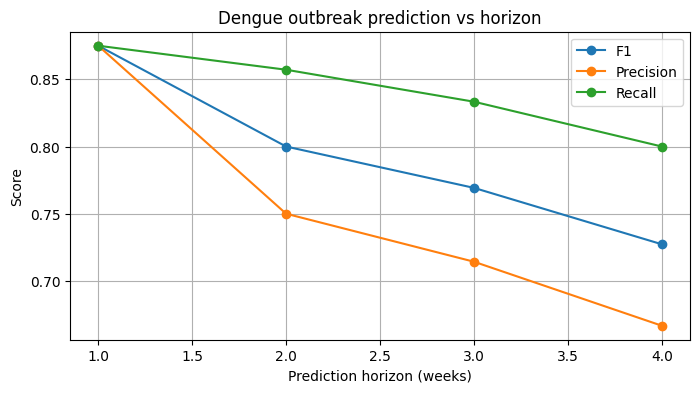

In [68]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df["horizon_weeks"], results_df["f1"], marker="o", label="F1")
ax.plot(results_df["horizon_weeks"], results_df["precision"], marker="o", label="Precision")
ax.plot(results_df["horizon_weeks"], results_df["recall"], marker="o", label="Recall")

ax.set_xlabel("Prediction horizon (weeks)")
ax.set_ylabel("Score")
ax.set_title("Dengue outbreak prediction vs horizon")
ax.legend()
ax.grid(True)


savefig(fig, "dengue_prediction_horizon_curve_baseline.png", subdir="dengue")
plt.show()

In [69]:
results_df

,horizon_weeks,f1,precision,recall,n_train,n_test
0,1,0.875000,0.875000,0.875000,102,155
1,2,0.800000,0.750000,0.857143,102,154
2,3,0.769231,0.714286,0.833333,102,153
3,4,0.727273,0.666667,0.800000,102,152


In [70]:
from pathlib import Path
from config import save_parquet

save_parquet(
    results_df,
    Path("../outputs/tables/dengue_results_df.parquet")
)

Saved parquet: ../outputs/tables/dengue_results_df.parquet


PosixPath('../outputs/tables/dengue_results_df.parquet')